In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Igor\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

df_baseVendas = pd.read_csv("vendas_livros.csv", encoding="utf-8", low_memory=False)

df_baseVendas.info()
display(df_baseVendas)


<class 'pandas.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_venda         625 non-null    int64  
 1   data_venda       625 non-null    str    
 2   livro            625 non-null    str    
 3   autor            625 non-null    str    
 4   categoria        625 non-null    str    
 5   preco_unitario   582 non-null    str    
 6   quantidade       615 non-null    float64
 7   cliente_id       625 non-null    str    
 8   cidade           625 non-null    str    
 9   forma_pagamento  506 non-null    str    
 10  canal_venda      625 non-null    str    
 11  avaliacao        498 non-null    str    
dtypes: float64(1), int64(1), str(10)
memory usage: 58.7 KB


,id_venda,data_venda,livro,autor,categoria,preco_unitario,quantidade,cliente_id,cidade,forma_pagamento,canal_venda,avaliacao
0,174,19/07/2025,1984,George Orwell,Ficção,"R$40,85",2.0,CLI1084,salvador,Cartão de Débito,Loja Física,NaN
1,178,17/02/2025,Harry Potter e a Pedra Filosofal,J.K. Rowling,fantasia,27.13,1.0,CLI1153,CURITIBA,Pix,Telefone,cinco
2,76,14/03/2025,"Pai Rico, Pai Pobre",Robert Kiyosaki,NÃO-FICÇÃO,"R$ 76,20",5.0,CLI1173,OSASCO,Cartão de Débito,Marketplace,4
3,17,25/07/25,O Hobbit,J.R.R. Tolkien,Fantasia,"R$31,54",5.0,CLI1042,São Paulo,Cartão de Débito,Site,1
4,562,13/11/25,"Pai Rico, Pai Pobre",Robert Kiyosaki,Não-ficção,"R$ 64,97",1.0,CLI1147,salvador,Cartão de Crédito,Loja Física,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
620,143,03/10/2025,Clean Code,Robert C. Martin,técnico,"R$72,21",2.0,CLI1143,BH,Pix,Loja Física,5
621,33,24/01/25,Clean Code,Robert C. Martin,TECNICO,"R$41,63",2.0,CLI1121,sao paulo,NaN,Site,4
622,582,2025-05-31,A Menina que Roubava Livros,Markus Zusak,ficcao,"R$24,51",1.0,CLI1102,CURITIBA,Cartão de Crédito,Telefone,4
623,24,15/08/2025,A Menina que Roubava Livros,Markus Zusak,FICÇÃO,"R$73,88",2.0,CLI1180,São Paulo,Cartão de Débito,Site,NaN


In [4]:
df_baseVendas["categoria"] = df_baseVendas["categoria"].str.strip().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.title()
df_baseVendas["cidade"] = df_baseVendas["cidade"].str.strip().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.title()
df_baseVendas["livro"] = df_baseVendas["livro"].str.strip().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.title()
df_baseVendas["autor"] = df_baseVendas["autor"].str.strip().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.title()
df_baseVendas["forma_pagamento"] = df_baseVendas["forma_pagamento"].str.strip().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.title()
df_baseVendas["data_venda"] = pd.to_datetime(df_baseVendas["data_venda"], format="mixed")


display(df_baseVendas)



,id_venda,data_venda,livro,autor,categoria,preco_unitario,quantidade,cliente_id,cidade,forma_pagamento,canal_venda,avaliacao
0,174,2025-07-19,1984,George Orwell,Ficcao,"R$40,85",2.0,CLI1084,Salvador,Cartao De Debito,Loja Física,NaN
1,178,2025-02-17,Harry Potter E A Pedra Filosofal,J.K. Rowling,Fantasia,27.13,1.0,CLI1153,Curitiba,Pix,Telefone,cinco
2,76,2025-03-14,"Pai Rico, Pai Pobre",Robert Kiyosaki,Nao-Ficcao,"R$ 76,20",5.0,CLI1173,Osasco,Cartao De Debito,Marketplace,4
3,17,2025-07-25,O Hobbit,J.R.R. Tolkien,Fantasia,"R$31,54",5.0,CLI1042,Sao Paulo,Cartao De Debito,Site,1
4,562,2025-11-13,"Pai Rico, Pai Pobre",Robert Kiyosaki,Nao-Ficcao,"R$ 64,97",1.0,CLI1147,Salvador,Cartao De Credito,Loja Física,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
620,143,2025-03-10,Clean Code,Robert C. Martin,Tecnico,"R$72,21",2.0,CLI1143,Bh,Pix,Loja Física,5
621,33,2025-01-24,Clean Code,Robert C. Martin,Tecnico,"R$41,63",2.0,CLI1121,Sao Paulo,NaN,Site,4
622,582,2025-05-31,A Menina Que Roubava Livros,Markus Zusak,Ficcao,"R$24,51",1.0,CLI1102,Curitiba,Cartao De Credito,Telefone,4
623,24,2025-08-15,A Menina Que Roubava Livros,Markus Zusak,Ficcao,"R$73,88",2.0,CLI1180,Sao Paulo,Cartao De Debito,Site,NaN


In [5]:
df_baseVendas['preco_unitario'] = (
    df_baseVendas["preco_unitario"]
    .str.replace('R$', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
)


df_baseVendas["preco_unitario"] = pd.to_numeric(df_baseVendas["preco_unitario"], errors='coerce')

display(df_baseVendas)




,id_venda,data_venda,livro,autor,categoria,preco_unitario,quantidade,cliente_id,cidade,forma_pagamento,canal_venda,avaliacao
0,174,2025-07-19,1984,George Orwell,Ficcao,40.85,2.0,CLI1084,Salvador,Cartao De Debito,Loja Física,NaN
1,178,2025-02-17,Harry Potter E A Pedra Filosofal,J.K. Rowling,Fantasia,27.13,1.0,CLI1153,Curitiba,Pix,Telefone,cinco
2,76,2025-03-14,"Pai Rico, Pai Pobre",Robert Kiyosaki,Nao-Ficcao,76.20,5.0,CLI1173,Osasco,Cartao De Debito,Marketplace,4
3,17,2025-07-25,O Hobbit,J.R.R. Tolkien,Fantasia,31.54,5.0,CLI1042,Sao Paulo,Cartao De Debito,Site,1
4,562,2025-11-13,"Pai Rico, Pai Pobre",Robert Kiyosaki,Nao-Ficcao,64.97,1.0,CLI1147,Salvador,Cartao De Credito,Loja Física,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
620,143,2025-03-10,Clean Code,Robert C. Martin,Tecnico,72.21,2.0,CLI1143,Bh,Pix,Loja Física,5
621,33,2025-01-24,Clean Code,Robert C. Martin,Tecnico,41.63,2.0,CLI1121,Sao Paulo,NaN,Site,4
622,582,2025-05-31,A Menina Que Roubava Livros,Markus Zusak,Ficcao,24.51,1.0,CLI1102,Curitiba,Cartao De Credito,Telefone,4
623,24,2025-08-15,A Menina Que Roubava Livros,Markus Zusak,Ficcao,73.88,2.0,CLI1180,Sao Paulo,Cartao De Debito,Site,NaN


In [6]:
df_baseVendas["preco_unitario_teste"] = df_baseVendas["preco_unitario"].fillna(
    df_baseVendas.groupby(["livro", "autor", "categoria"])["preco_unitario"].transform("first")
)

df_baseVendas["preco_unitario"] = df_baseVendas["preco_unitario"].fillna(
    df_baseVendas.groupby(["livro", "autor", "categoria"])["preco_unitario"].transform("first")
)

#display(df_baseVendas.info())
#display(df_baseVendas)

df_baseVendas["quantidade"].unique()


array([ 2.,  1.,  5.,  3.,  4., -5., -1., -2., nan, -4., -3.])

In [7]:
df_baseVendas["quantidade"] = pd.to_numeric(
    df_baseVendas["quantidade"],
    errors="coerce"
)

df_baseVendas["quantidade"] = df_baseVendas["quantidade"].abs()

df_baseVendas["quantidade"] = df_baseVendas["quantidade"].astype("Int64")
df_baseVendas["quantidade"].value_counts(dropna=False)
display(df_baseVendas.head(50))

,id_venda,data_venda,livro,autor,categoria,preco_unitario,quantidade,cliente_id,cidade,forma_pagamento,canal_venda,avaliacao,preco_unitario_teste
0,174,2025-07-19,1984,George Orwell,Ficcao,40.85,2,CLI1084,Salvador,Cartao De Debito,Loja Física,NaN,40.85
1,178,2025-02-17,Harry Potter E A Pedra Filosofal,J.K. Rowling,Fantasia,27.13,1,CLI1153,Curitiba,Pix,Telefone,cinco,27.13
2,76,2025-03-14,"Pai Rico, Pai Pobre",Robert Kiyosaki,Nao-Ficcao,76.20,5,CLI1173,Osasco,Cartao De Debito,Marketplace,4,76.20
3,17,2025-07-25,O Hobbit,J.R.R. Tolkien,Fantasia,31.54,5,CLI1042,Sao Paulo,Cartao De Debito,Site,1,31.54
4,562,2025-11-13,"Pai Rico, Pai Pobre",Robert Kiyosaki,Nao-Ficcao,64.97,1,CLI1147,Salvador,Cartao De Credito,Loja Física,NaN,64.97
5,368,2025-11-08,Duna,Frank Herbert,Ficcao Cientifica,51.03,3,CLI1030,Curitiba,Boleto,Site,4,51.03
6,385,2026-01-16,O Poder Do Habito,Charles Duhigg,Nao Ficcao,70.31,4,CLI1152,Belo Horizonte,NaN,Site,cinco,70.31
7,81,2025-06-20,O Hobbit,J.R.R. Tolkien,Fantasia,34.75,1,CLI1032,Belo Horizonte,NaN,Loja Física,4,34.75
8,80,2025-02-20,Duna,Frank Herbert,Ficcao Cientifica,51.03,2,CLI1139,Osasco,Pix,Site,5,51.03
9,224,2025-06-17,Dom Casmurro,Machado De Assis,Classico,41.20,1,CLI1023,Sao Paulo,Boleto,Marketplace,3,41.20


In [8]:
# display(df_baseVendas["avaliacao"])

df_avaliacao = df_baseVendas["avaliacao"]

df_avaliacao = np.where(
    df_avaliacao == "cinco",
    5,
    df_avaliacao
)

df_baseVendas["avaliacao"] = df_avaliacao

df_baseVendas["avaliacao"] = pd.to_numeric(
    df_baseVendas["avaliacao"],
    errors="coerce"
)

df_baseVendas["avaliacao"] = df_baseVendas["avaliacao"].astype("Int64")
df_baseVendas["avaliacao"] = df_baseVendas["avaliacao"].astype("object")
df_baseVendas["avaliacao"] = df_baseVendas["avaliacao"].fillna("Sem Avaliacao")

display(df_baseVendas["avaliacao"].head(50))



0     Sem Avaliacao
1                 5
2                 4
3                 1
4     Sem Avaliacao
5                 4
6                 5
7                 4
8                 5
9                 3
10                5
11                5
12                2
13                3
14                2
15                4
16                5
17                2
18                5
19                4
20                5
21                5
22                4
23                2
24                5
25                5
26                5
27                4
28                1
29                1
30    Sem Avaliacao
31                3
32                4
33    Sem Avaliacao
34                4
35                4
36    Sem Avaliacao
37    Sem Avaliacao
38                1
39                5
40                1
41                4
42                4
43                4
44    Sem Avaliacao
45                1
46                4
47    Sem Avaliacao
48    Sem Avaliacao
49                4


In [9]:
df_baseVendas["forma_pagamento"] = df_baseVendas["forma_pagamento"].fillna("Nao Informado")
display(df_baseVendas["forma_pagamento"].head(50))

0      Cartao De Debito
1                   Pix
2      Cartao De Debito
3      Cartao De Debito
4     Cartao De Credito
5                Boleto
6         Nao Informado
7         Nao Informado
8                   Pix
9                Boleto
10    Cartao De Credito
11    Cartao De Credito
12               Boleto
13     Cartao De Debito
14        Nao Informado
15        Nao Informado
16               Boleto
17               Boleto
18    Cartao De Credito
19                  Pix
20               Boleto
21     Cartao De Debito
22    Cartao De Credito
23     Cartao De Debito
24        Nao Informado
25                  Pix
26               Boleto
27        Nao Informado
28                  Pix
29        Nao Informado
30               Boleto
31    Cartao De Credito
32    Cartao De Credito
33                  Pix
34                  Pix
35    Cartao De Credito
36               Boleto
37    Cartao De Credito
38                  Pix
39    Cartao De Credito
40     Cartao De Debito
41        Nao In

In [10]:
df_baseVendas["cidade"].value_counts()

df_cidade = df_baseVendas["cidade"]

dic_cidade = {
    "S. Paulo" : "Sao Paulo", "Rj":"Rio De Janeiro", "Bh":"Belo Horizonte"
}
df_cidade = df_cidade.replace(dic_cidade)

df_baseVendas["cidade"] = df_cidade
df_baseVendas["cidade"].unique()

<StringArray>
[      'Salvador',       'Curitiba',         'Osasco',      'Sao Paulo',
 'Belo Horizonte', 'Rio De Janeiro']
Length: 6, dtype: str

In [11]:
df_baseVendas["categoria"].value_counts()

dic_categoria = {
    "Nao-Ficcao" : "Nao Ficcao"
}

df_baseVendas["categoria"] = df_baseVendas["categoria"].replace(dic_categoria)

df_baseVendas["categoria"].unique()


<StringArray>
['Ficcao', 'Fantasia', 'Nao Ficcao', 'Ficcao Cientifica', 'Classico',
 'Tecnico']
Length: 6, dtype: str

In [12]:
df_baseVendas = df_baseVendas.drop(columns=["preco_unitario_teste"])
display(df_baseVendas.info())


<class 'pandas.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_venda         625 non-null    int64         
 1   data_venda       625 non-null    datetime64[us]
 2   livro            625 non-null    str           
 3   autor            625 non-null    str           
 4   categoria        625 non-null    str           
 5   preco_unitario   625 non-null    float64       
 6   quantidade       615 non-null    Int64         
 7   cliente_id       625 non-null    str           
 8   cidade           625 non-null    str           
 9   forma_pagamento  625 non-null    str           
 10  canal_venda      625 non-null    str           
 11  avaliacao        625 non-null    object        
dtypes: Int64(1), datetime64[us](1), float64(1), int64(1), object(1), str(7)
memory usage: 59.3+ KB


None

In [13]:
#df_baseVendas["id_venda"].value_counts()
display(df_baseVendas)
df_baseVendas = df_baseVendas.drop_duplicates()


,id_venda,data_venda,livro,autor,categoria,preco_unitario,quantidade,cliente_id,cidade,forma_pagamento,canal_venda,avaliacao
0,174,2025-07-19,1984,George Orwell,Ficcao,40.85,2,CLI1084,Salvador,Cartao De Debito,Loja Física,Sem Avaliacao
1,178,2025-02-17,Harry Potter E A Pedra Filosofal,J.K. Rowling,Fantasia,27.13,1,CLI1153,Curitiba,Pix,Telefone,5
2,76,2025-03-14,"Pai Rico, Pai Pobre",Robert Kiyosaki,Nao Ficcao,76.20,5,CLI1173,Osasco,Cartao De Debito,Marketplace,4
3,17,2025-07-25,O Hobbit,J.R.R. Tolkien,Fantasia,31.54,5,CLI1042,Sao Paulo,Cartao De Debito,Site,1
4,562,2025-11-13,"Pai Rico, Pai Pobre",Robert Kiyosaki,Nao Ficcao,64.97,1,CLI1147,Salvador,Cartao De Credito,Loja Física,Sem Avaliacao
...,...,...,...,...,...,...,...,...,...,...,...,...
620,143,2025-03-10,Clean Code,Robert C. Martin,Tecnico,72.21,2,CLI1143,Belo Horizonte,Pix,Loja Física,5
621,33,2025-01-24,Clean Code,Robert C. Martin,Tecnico,41.63,2,CLI1121,Sao Paulo,Nao Informado,Site,4
622,582,2025-05-31,A Menina Que Roubava Livros,Markus Zusak,Ficcao,24.51,1,CLI1102,Curitiba,Cartao De Credito,Telefone,4
623,24,2025-08-15,A Menina Que Roubava Livros,Markus Zusak,Ficcao,73.88,2,CLI1180,Sao Paulo,Cartao De Debito,Site,Sem Avaliacao


In [14]:
display(df_baseVendas.info())

<class 'pandas.DataFrame'>
Index: 601 entries, 0 to 623
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_venda         601 non-null    int64         
 1   data_venda       601 non-null    datetime64[us]
 2   livro            601 non-null    str           
 3   autor            601 non-null    str           
 4   categoria        601 non-null    str           
 5   preco_unitario   601 non-null    float64       
 6   quantidade       591 non-null    Int64         
 7   cliente_id       601 non-null    str           
 8   cidade           601 non-null    str           
 9   forma_pagamento  601 non-null    str           
 10  canal_venda      601 non-null    str           
 11  avaliacao        601 non-null    object        
dtypes: Int64(1), datetime64[us](1), float64(1), int64(1), object(1), str(7)
memory usage: 61.6+ KB


None

In [15]:
#Retirei valores nulos de quantidade para os calculos seguintes, porém mantive as linhas na base original
df_baseVendas[df_baseVendas["quantidade"].isna()]

df_analise = df_baseVendas[df_baseVendas["quantidade"].notna()].copy()

np.float64(127.13719120135364)

<Axes: xlabel='canal_venda'>

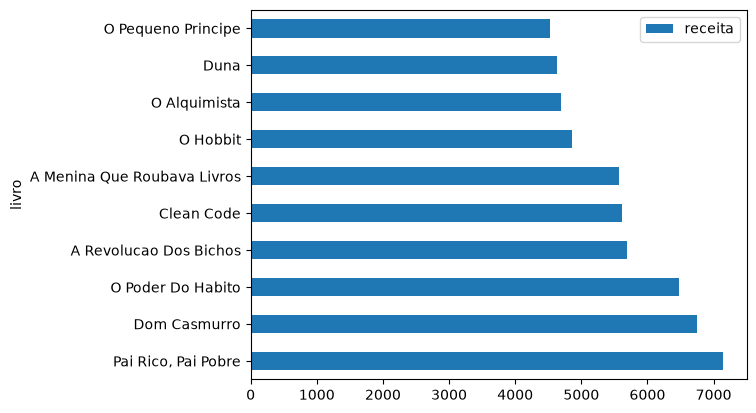

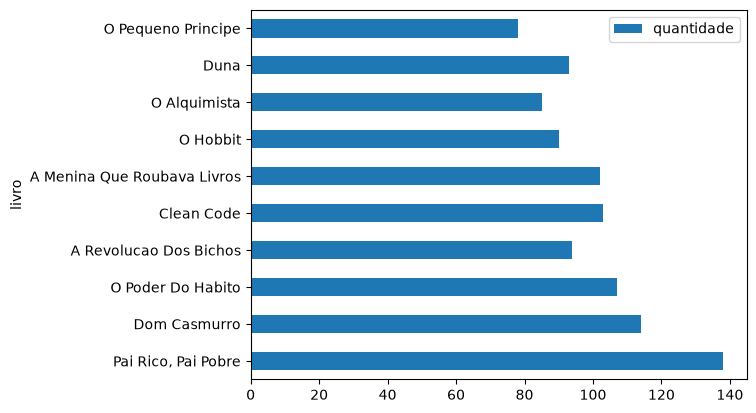

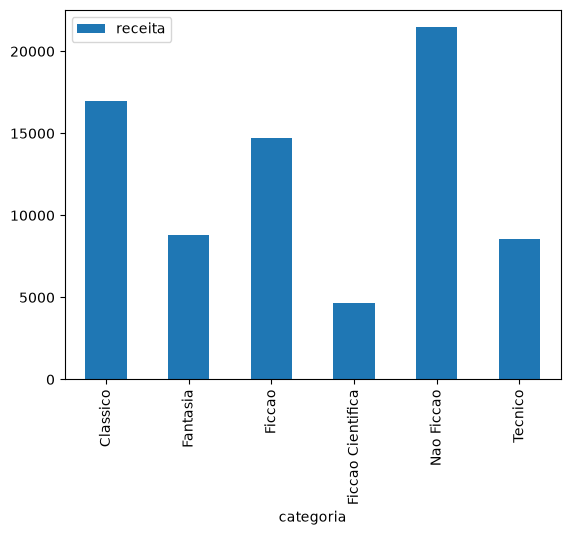

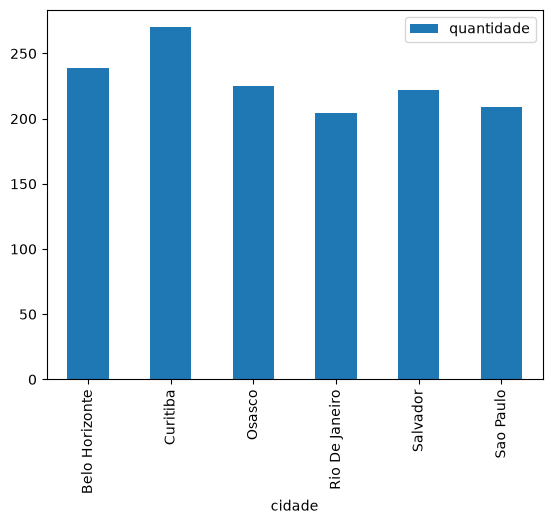

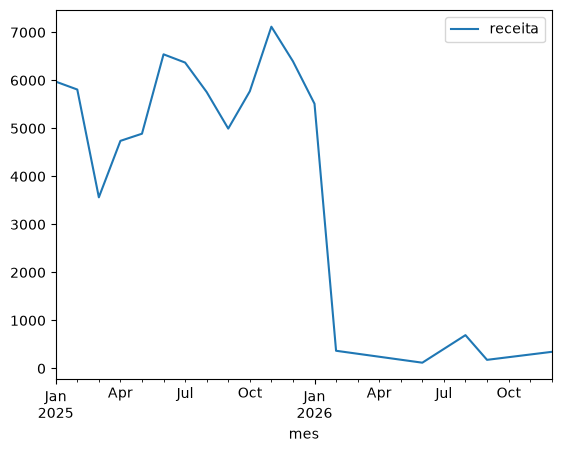

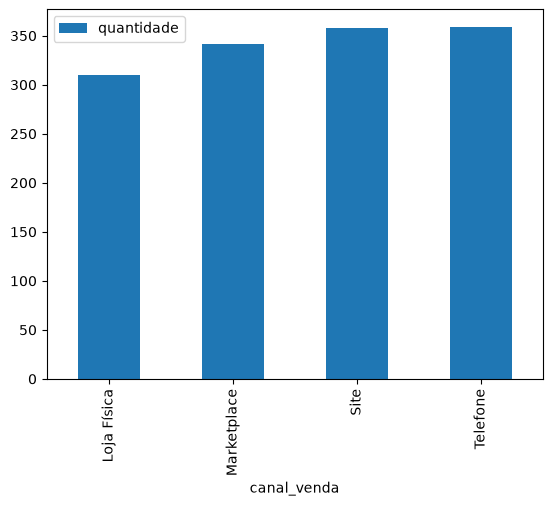

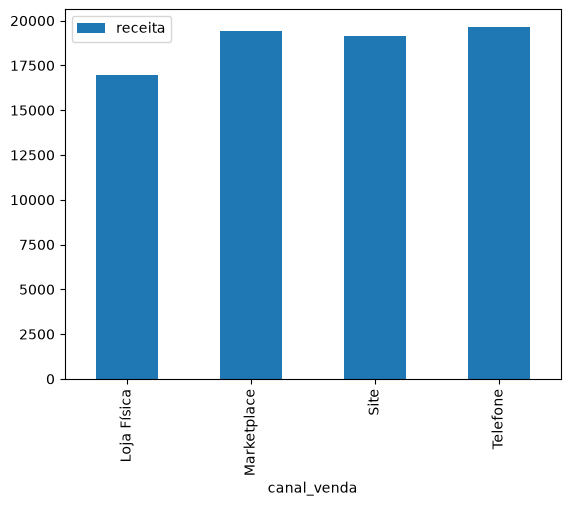

In [16]:
#Livro mais vendido

df_analise["receita"] = df_analise["preco_unitario"] * df_analise["quantidade"]

df_livro_melhor = df_analise[["livro", "receita", "quantidade"]].groupby("livro", as_index=False).sum()
df_livro_melhor = df_livro_melhor.sort_values(by=["receita", "quantidade"], ascending=False)
df_livro_melhor = df_livro_melhor[:10]
df_livro_melhor.plot(x="livro", y="receita",kind="barh")
df_livro_melhor.plot(x="livro", y="quantidade",kind="barh")

#Categoria com mais receita

df_categoria_receita = df_analise[["categoria", "receita"]].groupby("categoria", as_index=False).sum()
df_categoria_receita.plot(y="receita", x="categoria",kind="bar")

#Cidade que mais compra

df_categoria_receita = df_analise[["cidade", "quantidade"]].groupby("cidade", as_index=False).sum()
df_categoria_receita.plot(y="quantidade", x="cidade",kind="bar")

#Sazonalidade por mês

df_analise["mes"] = df_analise["data_venda"].dt.to_period("M")
df_mes_venda = df_analise[["mes", "receita"]].groupby("mes", as_index=False).sum()
df_mes_venda.plot(y="receita", x="mes",kind="line")

#Ticket médio

ticket_medio = df_analise["receita"].sum() / df_analise["id_venda"].nunique()
display(ticket_medio)

#Canal de venda que performa melhor

df_canal_venda = df_analise[["canal_venda", "quantidade", "receita"]].groupby("canal_venda", as_index=False).sum()
df_canal_venda.plot(y="quantidade", x="canal_venda", kind="bar")
df_canal_venda.plot(y="receita", x="canal_venda", kind="bar")